In [1]:
from sklearn.datasets import make_classification
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial import Voronoi, voronoi_plot_2d


from __future__ import division
import numpy as np
from numpy.random import rand
import matplotlib.pyplot as plt
import matplotlib as mpl
from numba import jit
import os
import re
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sys import exit

In [2]:
plt.rcParams.update({'font.size': 12,
                     'lines.linewidth': 0.5,
                     'lines.markersize': 3,
                     "font.family": "serif",
                     'font.weight': 'normal',
                     "mathtext.fontset" : "stix",
                     "figure.dpi":200,
                     "legend.title_fontsize":12,
                     "legend.fontsize":9
                     })

In [3]:
def sort_beta(file):
    #print(file)
    beta = re.search('beta_(.+?)_', file).group(1)
    return float(beta)

In [4]:
@jit(nopython=True)
def StaggeredMagnetization(data, N):
    #print(data)
    
    #You have to unravel the array in a snake path (-_-)
    data = np.where(np.arange(len(data))[:,None]%2,data[:,::-1],data).ravel()
    
    #print(data)
    
    staggered_magnetization =np.zeros(N**2)
    for i in range(N**2):
        staggered_magnetization[i]=((-1)**(i))*data[i]
        
    result = np.sum(staggered_magnetization)/(N**2)
    return(result)

@jit(nopython=True)
def AntiferroOrderParam_SquareLattice(data, N):
    total_order = 0
    #print(N)
    #print(data)
    for a in range(N):
        for b in range(N):
            nb = np.zeros(4)
            spin = data[a,b]
            #print(spin)
            nb[0] = data[(a+1)%N,b] 
            nb[1] = data[a,(b+1)%N] 
            nb[2] = data[(a-1)%N,b] 
            nb[3] = data[a,(b-1)%N]
            
            order = 0
            for i in range(4):
                if spin * nb[i]== -1:
                    order+=1
                else: order+=0
            order/=4
            #print(nb)
            total_order += order
    return(total_order/(N**2))
            


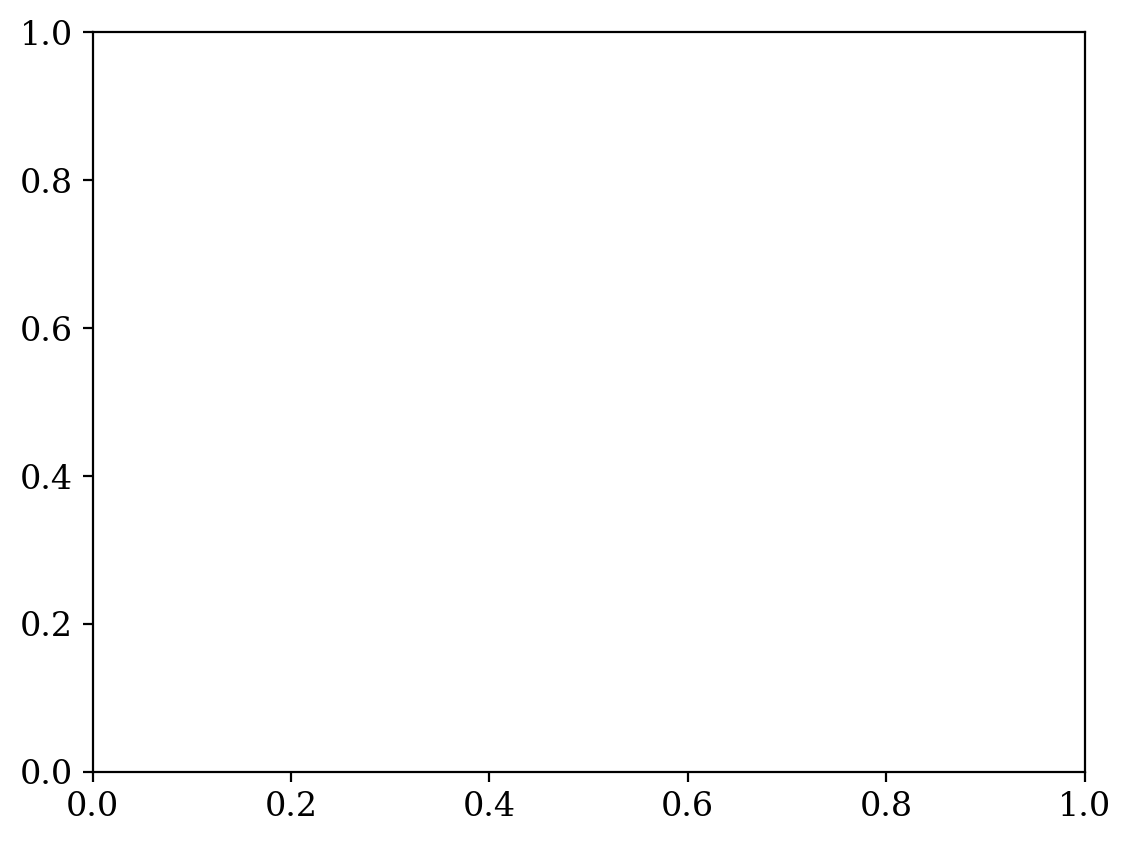

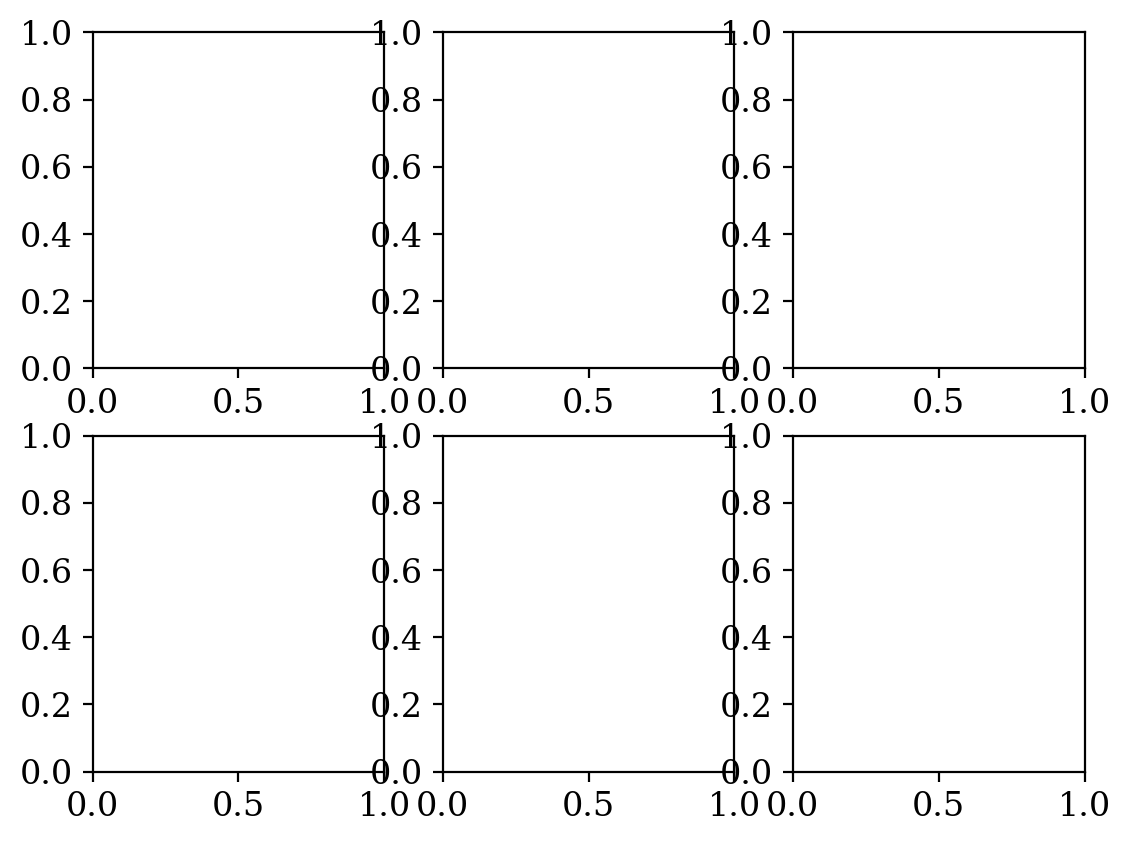

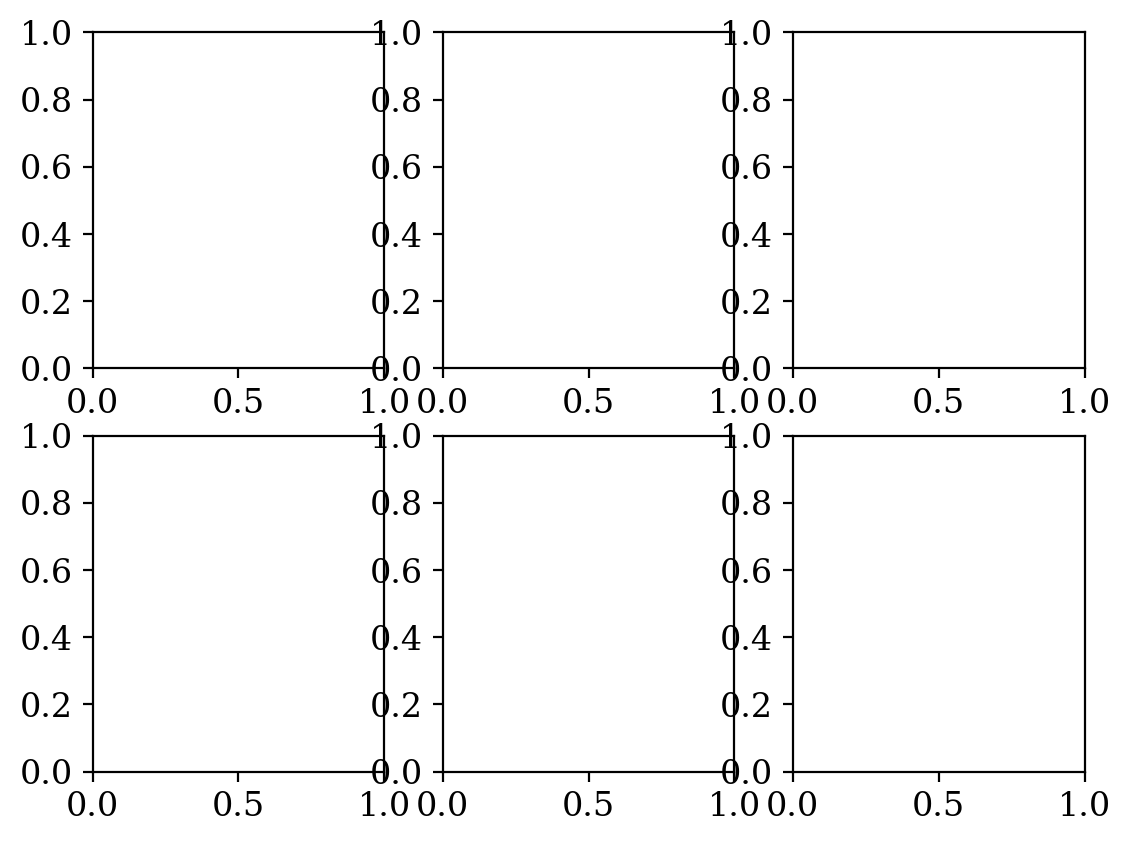

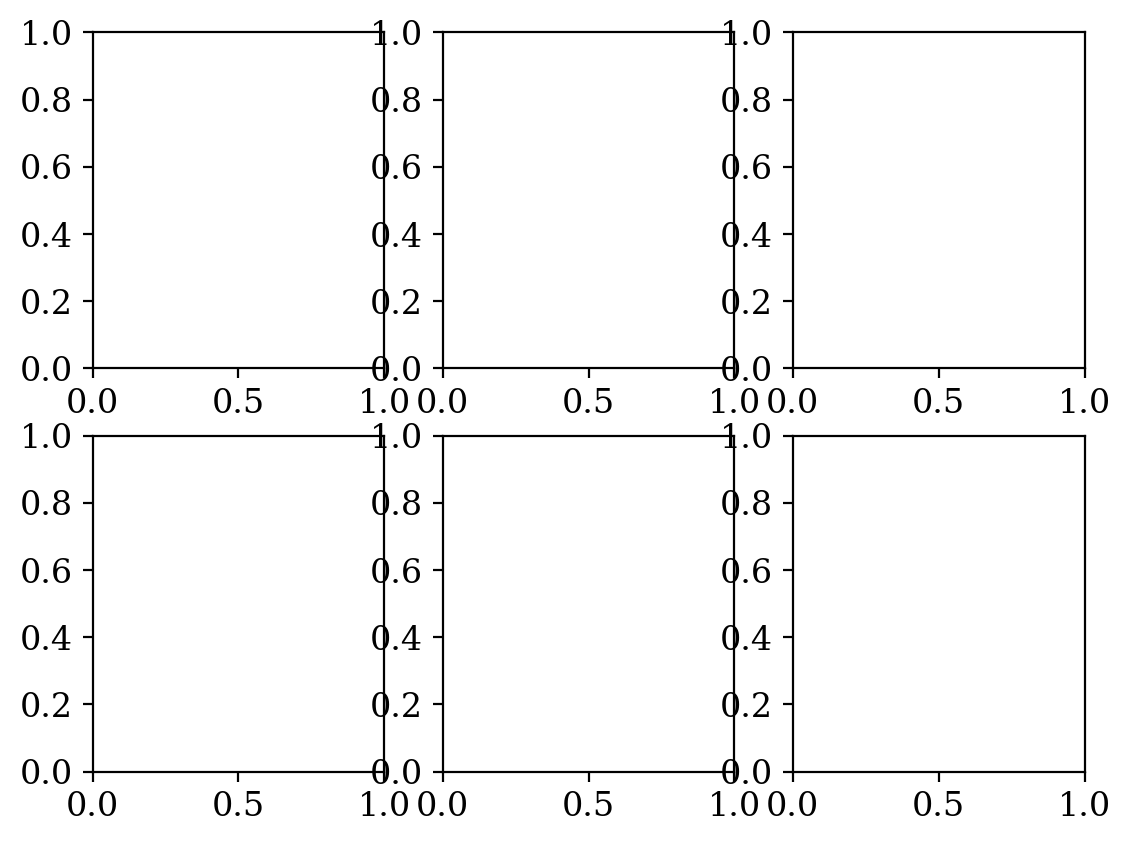

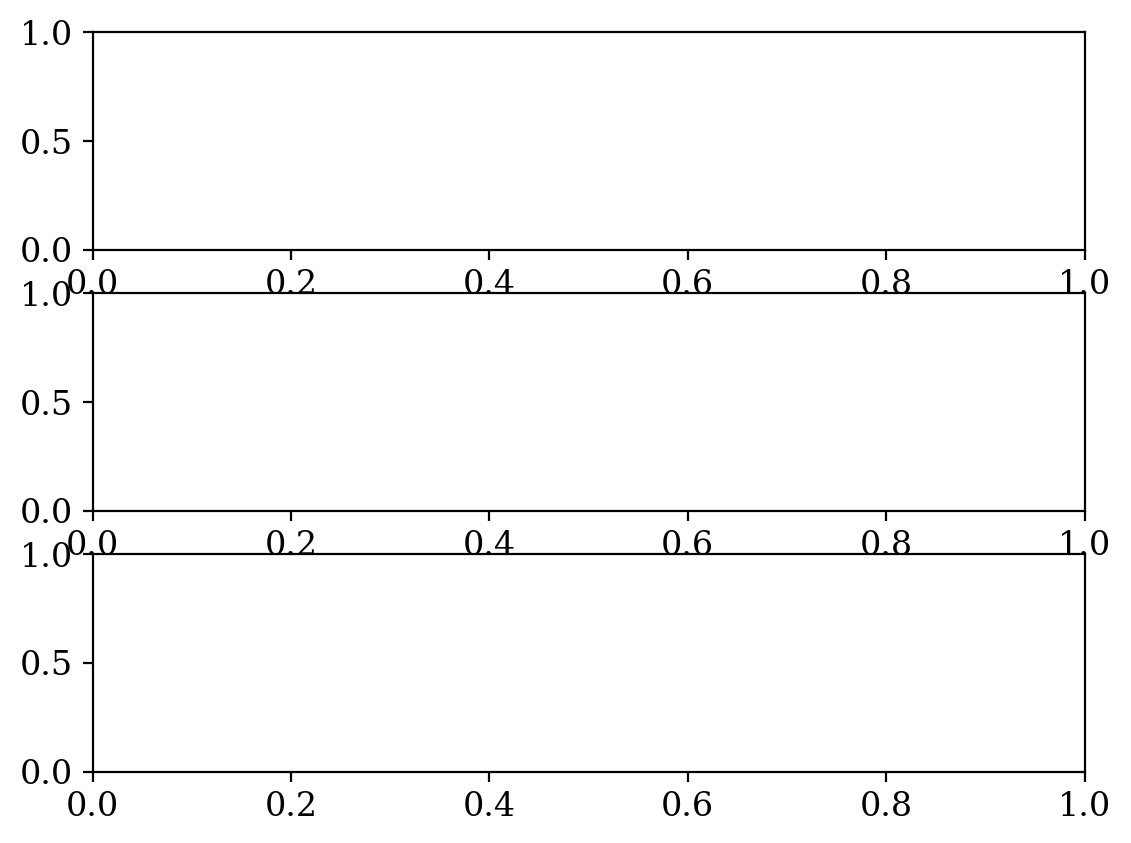

In [5]:
fig_varPCA, ax_varPCA = plt.subplots();

#fig_tSNE_1, ax_tSNE_1 = plt.subplots();
fig_PCA_1, ax_PCA_1 = plt.subplots(2, 3)#, figsize=(15, 15));

#fig_tSNE_2, ax_tSNE_2 = plt.subplots();
fig_PCA_2, ax_PCA_2 = plt.subplots(2, 3)#, figsize=(15, 15));

#fig_tSNE_3, ax_tSNE_3 = plt.subplots();
fig_PCA_3, ax_PCA_3 = plt.subplots(2, 3)#, figsize=(15, 15));

fig_PCA_Circular, ax_PCA_Circular =  plt.subplots( 3)#, figsize =(15,15));

In [6]:
N =30
type_folder = 'Hex_antiferro_v2'

(2000, 30, 30)
5.5


/var/folders/c3/v12nq2x14cq73wqt20_541t80000gp/T/ipykernel_22771/1116483063.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X= torch.tensor(X, dtype=torch.float)
/var/folders/c3/v12nq2x14cq73wqt20_541t80000gp/T/ipykernel_22771/1116483063.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y= torch.tensor(y, dtype=torch.long)


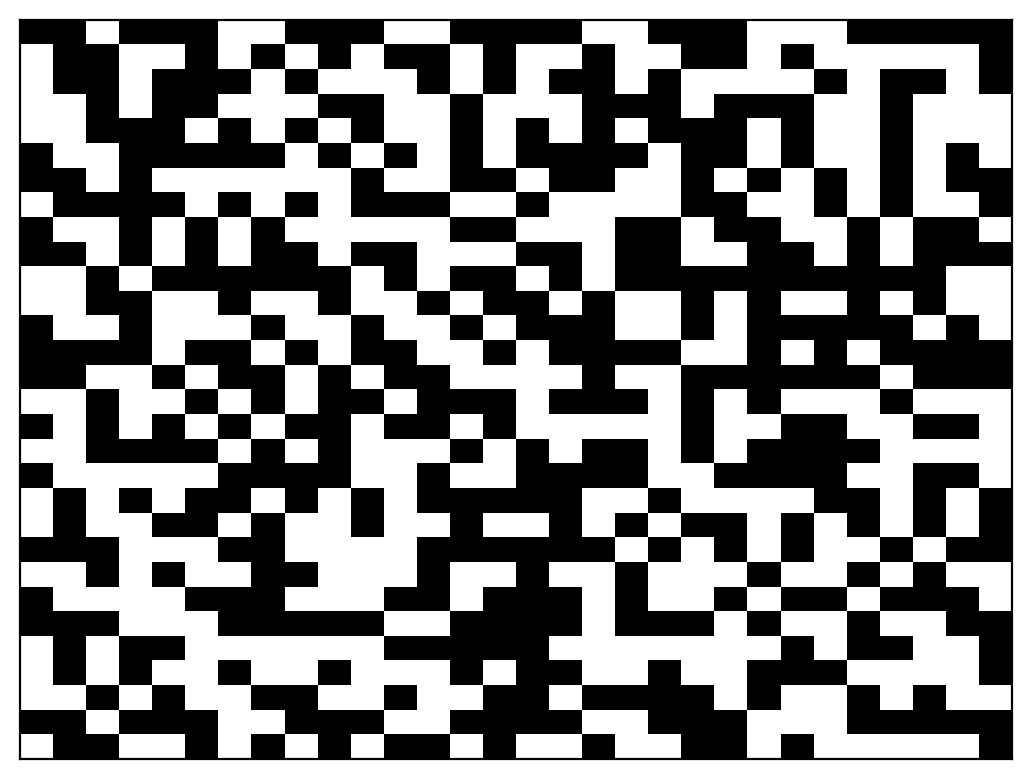

In [7]:
numCopies = 1

inputfolder ='./'+type_folder+'/data_N_'+str(N)+'_test'
myfiles = os.listdir(inputfolder)
#myfiles.remove('.DS_Store')
myfiles.sort(key = sort_beta)

betas= []
labels = []
data = np.zeros((  int(len(myfiles)) ,N,N))
for i in range(len(myfiles)):
    #print(myfiles[i])

    beta = re.search('beta_(.+?)_', myfiles[i]).group(1)
    betas.append(float(beta))
    data[i,:] = np.loadtxt(inputfolder+'/'+str(myfiles[i]))
    if 1/float(beta) > 2.269:
        labels.append(0) #paramagnet above Tc
    else: labels.append(1) #ferromagnet below Tc

data = np.repeat(data, numCopies, axis=0)
print(data.shape)
#     N=2
#     data=data[:,:N, :N]
#     print(data.shape)

#     #flip half of the spins at each temperature to double configurations in data
#     for i in range(int(len(data)/int(numCopies/2))):
#         if (i % 2) == 0:
#             #print(i*int(numCopies/2),(i+1)*int(numCopies/2))
#             data[i*int(numCopies/2):(i+1)*int(numCopies/2)]*=-1


X = torch.from_numpy(data)
X= torch.tensor(X, dtype=torch.float)

X = X.reshape(X.shape[0], -1)

#print(tsne.kl_divergence_)
#print(X_tsne)

y = np.asarray(labels)
y=np.repeat(y,numCopies)

#print(y.shape)
y = torch.from_numpy(y)
y= torch.tensor(y, dtype=torch.long)


betas=np.asarray(betas)
betas = np.repeat(betas, numCopies)
Temps = 1/betas

Xfig, Yfig = np.meshgrid(range(N), range(N))
plt.figure() 
#plt.setp(sp.get_yticklabels(), visible=False)
#plt.setp(sp.get_xticklabels(), visible=False)      
plt.pcolormesh(Xfig, Yfig, data[0], cmap=plt.cm.binary);
# getting current axes
a = plt.gca()

# set visibility of x-axis as False
xax = a.axes.get_xaxis()
xax = xax.set_visible(False)

# set visibility of y-axis as False
yax = a.axes.get_yaxis()
yax = yax.set_visible(False)
plt.axis('tight') 
print(1/betas[0])

#First color map

c_norm = mpl.colors.Normalize(vmin=np.min(Temps), vmax=np.max(Temps))

c_map  = mpl.cm.RdYlBu_r

s_map  = mpl.cm.ScalarMappable(cmap=c_map, norm=c_norm)
s_map.set_array([])

#Second color map

c_norm2 = mpl.colors.Normalize(vmin=-1, vmax=1)

c_map2  = mpl.cm.RdYlBu_r

s_map2  = mpl.cm.ScalarMappable(cmap=c_map2, norm=c_norm2)
s_map2.set_array([])

#Third color map

c_norm3 = mpl.colors.Normalize(vmin=0, vmax=1)

c_map3  = mpl.cm.RdYlBu_r

s_map3  = mpl.cm.ScalarMappable(cmap=c_map3, norm=c_norm3)
s_map3.set_array([])




In [8]:
#Dimensionality Reduction
pca = PCA(n_components = 0.99)
X_pca = pca.fit_transform(X)
print(X_pca.shape)
variance_PCA = pca.explained_variance_ratio_

#tsne = TSNE(n_components=2)
#X_tsne = tsne.fit_transform(X)

kmeans_PCA = KMeans(init='k-means++', n_clusters=3, n_init='auto')
kmeans_PCA.fit(X_pca)

centroids_PCA = kmeans_PCA.cluster_centers_

#kmeans_tSNE = KMeans(init='k-means++', n_clusters=3, n_init='auto')
#kmeans_tSNE.fit(X_tsne)

#centroids_tSNE = kmeans_tSNE.cluster_centers_

(2000, 718)


In [9]:
#Compute order parameters and make color map
order_param = np.zeros(len(X_pca))
staggered_magnetization = np.zeros(len(X_pca))
magnetization = np.zeros(len(X_pca))
colors_Temp = []
colors_Magnetization = []
colors_Stagg_Magnetization = []

for p in range(len(X_pca)):
    magnetization[p] = np.sum(data[p])/(N**2)
    staggered_magnetization[p] = StaggeredMagnetization( data[p], N)
    colors_Temp.append(s_map.to_rgba(float(Temps[p])))
    colors_Magnetization.append(s_map2.to_rgba(float(magnetization[p])))
    colors_Stagg_Magnetization.append(s_map2.to_rgba(float(staggered_magnetization[p])))

colors_Temp = np.asarray(colors_Temp)
colors_Magnetization = np.asarray(colors_Magnetization)
colors_Stagg_Magnetization = np.asarray(colors_Stagg_Magnetization)

print(staggered_magnetization)

[-0.04222222  0.04222222 -0.04444444 ... -0.00666667  0.03555556
  0.00222222]


In [10]:
ax_PCA_Circular[0].scatter(X_pca[:, 0]**2 + X_pca[:, 1]**2, X_pca[:, 2]**2 + X_pca[:, 3]**2, 
                             color = colors_Temp, s=3, edgecolors='black', linewidth=0.25)

ax_PCA_Circular[1].scatter(X_pca[:, 0]**2 + X_pca[:, 2]**2, X_pca[:, 1]**2 + X_pca[:, 3]**2, 
                             color = colors_Temp, s=3, edgecolors='black', linewidth=0.25)

ax_PCA_Circular[2].scatter(X_pca[:, 0]**2 + X_pca[:, 3]**2, X_pca[:, 1]**2 + X_pca[:, 2]**2, 
                             color = colors_Temp, s=3, edgecolors='black', linewidth=0.25)

ax_PCA_Circular[ 0].set_xticks([])
ax_PCA_Circular[ 0].set_yticks([])

ax_PCA_Circular[ 1].set_xticks([])
ax_PCA_Circular[ 1].set_yticks([])

ax_PCA_Circular[ 2].set_xticks([])
ax_PCA_Circular[ 2].set_yticks([])

ax_PCA_Circular[0].set_xlabel(r'$c_1^{2} + c_2^{2}$', fontsize=18)
ax_PCA_Circular[0].set_ylabel(r'$c_3^{2} + c_4^{2}$', fontsize=18)

ax_PCA_Circular[1].set_xlabel(r'$c_1^{2} + c_3^{2}$', fontsize=18)
ax_PCA_Circular[1].set_ylabel(r'$c_2^{2} + c_4^{2}$', fontsize=18)

ax_PCA_Circular[2].set_xlabel(r'$c_1^{2} + c_4^{2}$', fontsize=18)
ax_PCA_Circular[2].set_ylabel(r'$c_2^{2} + c_3^{2}$', fontsize=18)


Text(8.888888888888903, 0.5, '$c_2^{2} + c_3^{2}$')

In [11]:
#ax_tSNE_1.scatter(X_tsne[p, 0], X_tsne[p, 1], color = s_map.to_rgba(float(Temps[p])), s=1)
ax_PCA_1[0,0].scatter(X_pca[:, 0], X_pca[:, 1], color = colors_Temp, s=3, edgecolors='black', linewidth=0.25)
ax_PCA_1[0,1].scatter(X_pca[:, 0], X_pca[:, 2], color = colors_Temp, s=3, edgecolors='black', linewidth=0.25)
ax_PCA_1[0,2].scatter(X_pca[:, 0], X_pca[:, 3], color = colors_Temp, s=3, edgecolors='black', linewidth=0.25)
ax_PCA_1[1,0].scatter(X_pca[:, 1], X_pca[:, 2], color = colors_Temp, s=3, edgecolors='black', linewidth=0.25)
ax_PCA_1[1,1].scatter(X_pca[:, 1], X_pca[:, 3], color = colors_Temp, s=3, edgecolors='black', linewidth=0.25)
ax_PCA_1[1,2].scatter(X_pca[:, 2], X_pca[:, 3], color = colors_Temp, s=3, edgecolors='black', linewidth=0.25)

ax_PCA_1[0, 0].set_xticks([])
ax_PCA_1[0, 1].set_xticks([])
ax_PCA_1[0, 2].set_xticks([])
ax_PCA_1[1, 0].set_xticks([])
ax_PCA_1[1, 1].set_xticks([])
ax_PCA_1[1, 2].set_xticks([])

ax_PCA_1[0, 0].set_yticks([])
ax_PCA_1[0, 1].set_yticks([])
ax_PCA_1[0, 2].set_yticks([])
ax_PCA_1[1, 0].set_yticks([])
ax_PCA_1[1, 1].set_yticks([])
ax_PCA_1[1, 2].set_yticks([])

ax_PCA_1[0, 0].set_xlabel(r'$c_1$')
ax_PCA_1[0, 0].set_ylabel(r'$c_2$')

ax_PCA_1[0, 1].set_xlabel(r'$c_1$')
ax_PCA_1[0, 1].set_ylabel(r'$c_3$')

ax_PCA_1[0, 2].set_xlabel(r'$c_1$')
ax_PCA_1[0, 2].set_ylabel(r'$c_4$')

ax_PCA_1[1, 0].set_xlabel(r'$c_2$')
ax_PCA_1[1, 0].set_ylabel(r'$c_3$')

ax_PCA_1[1, 1].set_xlabel(r'$c_2$')
ax_PCA_1[1, 1].set_ylabel(r'$c_4$')

ax_PCA_1[1, 2].set_xlabel(r'$c_3$')
ax_PCA_1[1, 2].set_ylabel(r'$c_4$')

Text(709.124183006536, 0.5, '$c_4$')

In [12]:

#ax_tSNE_2.scatter(X_tsne[p, 0], X_tsne[p, 1], color = s_map2.to_rgba(magnetization[p]), s=1)
ax_PCA_2[0,0].scatter(X_pca[:, 0], X_pca[:, 1], color = colors_Magnetization , s=3, edgecolors='black', linewidth=0.25)
ax_PCA_2[0,1].scatter(X_pca[:, 0], X_pca[:, 2], color = colors_Magnetization , s=3, edgecolors='black', linewidth=0.25)
ax_PCA_2[0,2].scatter(X_pca[:, 0], X_pca[:, 3], color = colors_Magnetization , s=3, edgecolors='black', linewidth=0.25)
ax_PCA_2[1,0].scatter(X_pca[:, 1], X_pca[:, 2], color = colors_Magnetization , s=3, edgecolors='black', linewidth=0.25)
ax_PCA_2[1,1].scatter(X_pca[:, 1], X_pca[:, 3], color = colors_Magnetization , s=3, edgecolors='black', linewidth=0.25)
ax_PCA_2[1,2].scatter(X_pca[:, 2], X_pca[:, 3], color = colors_Magnetization , s=3, edgecolors='black', linewidth=0.25)


ax_PCA_2[0, 0].set_xticks([])
ax_PCA_2[0, 1].set_xticks([])
ax_PCA_2[0, 2].set_xticks([])
ax_PCA_2[1, 0].set_xticks([])
ax_PCA_2[1, 1].set_xticks([])
ax_PCA_2[1, 2].set_xticks([])

ax_PCA_2[0, 0].set_yticks([])
ax_PCA_2[0, 1].set_yticks([])
ax_PCA_2[0, 2].set_yticks([])
ax_PCA_2[1, 0].set_yticks([])
ax_PCA_2[1, 1].set_yticks([])
ax_PCA_2[1, 2].set_yticks([])

ax_PCA_2[0, 0].set_xlabel(r'$c_1$')
ax_PCA_2[0, 0].set_ylabel(r'$c_2$')

ax_PCA_2[0, 1].set_xlabel(r'$c_1$')
ax_PCA_2[0, 1].set_ylabel(r'$c_3$')

ax_PCA_2[0, 2].set_xlabel(r'$c_1$')
ax_PCA_2[0, 2].set_ylabel(r'$c_4$')

ax_PCA_2[1, 0].set_xlabel(r'$c_2$')
ax_PCA_2[1, 0].set_ylabel(r'$c_3$')

ax_PCA_2[1, 1].set_xlabel(r'$c_2$')
ax_PCA_2[1, 1].set_ylabel(r'$c_4$')

ax_PCA_2[1, 2].set_xlabel(r'$c_3$')
ax_PCA_2[1, 2].set_ylabel(r'$c_4$')

Text(709.124183006536, 0.5, '$c_4$')

In [13]:


#ax_tSNE_3.scatter(X_tsne[p, 0], X_tsne[p, 1], color = s_map2.to_rgba(staggered_magnetization[p]), s=1)
ax_PCA_3[0,0].scatter(X_pca[:, 0], X_pca[:, 1], color = colors_Stagg_Magnetization, s=3, edgecolors='black', linewidth=0.25)
ax_PCA_3[0,1].scatter(X_pca[:, 0], X_pca[:, 2], color = colors_Stagg_Magnetization, s=3, edgecolors='black', linewidth=0.25)
ax_PCA_3[0,2].scatter(X_pca[:, 0], X_pca[:, 3], color = colors_Stagg_Magnetization, s=3, edgecolors='black', linewidth=0.25)
ax_PCA_3[1,0].scatter(X_pca[:, 1], X_pca[:, 2], color = colors_Stagg_Magnetization, s=3, edgecolors='black', linewidth=0.25)
ax_PCA_3[1,1].scatter(X_pca[:, 1], X_pca[:, 3], color = colors_Stagg_Magnetization, s=3, edgecolors='black', linewidth=0.25)
ax_PCA_3[1,2].scatter(X_pca[:, 2], X_pca[:, 3], color = colors_Stagg_Magnetization, s=3, edgecolors='black', linewidth=0.25)

ax_PCA_3[0, 0].set_xticks([])
ax_PCA_3[0, 1].set_xticks([])
ax_PCA_3[0, 2].set_xticks([])
ax_PCA_3[1, 0].set_xticks([])
ax_PCA_3[1, 1].set_xticks([])
ax_PCA_3[1, 2].set_xticks([])

ax_PCA_3[0, 0].set_yticks([])
ax_PCA_3[0, 1].set_yticks([])
ax_PCA_3[0, 2].set_yticks([])
ax_PCA_3[1, 0].set_yticks([])
ax_PCA_3[1, 1].set_yticks([])
ax_PCA_3[1, 2].set_yticks([])

ax_PCA_3[0, 0].set_xlabel(r'$c_1$')
ax_PCA_3[0, 0].set_ylabel(r'$c_2$')

ax_PCA_3[0, 1].set_xlabel(r'$c_1$')
ax_PCA_3[0, 1].set_ylabel(r'$c_3$')

ax_PCA_3[0, 2].set_xlabel(r'$c_1$')
ax_PCA_3[0, 2].set_ylabel(r'$c_4$')

ax_PCA_3[1, 0].set_xlabel(r'$c_2$')
ax_PCA_3[1, 0].set_ylabel(r'$c_3$')

ax_PCA_3[1, 1].set_xlabel(r'$c_2$')
ax_PCA_3[1, 1].set_ylabel(r'$c_4$')

ax_PCA_3[1, 2].set_xlabel(r'$c_3$')
ax_PCA_3[1, 2].set_ylabel(r'$c_4$')

Text(709.124183006536, 0.5, '$c_4$')

In [14]:
fig_PCA_1.suptitle('PCA '+str(N)+'x'+str(N)+' '+ type_folder)
fig_PCA_2.suptitle('PCA '+str(N)+'x'+str(N)+' '+ type_folder)
fig_PCA_3.suptitle('PCA '+str(N)+'x'+str(N)+' '+ type_folder)

ax_varPCA.plot(np.arange(1, 11), variance_PCA[:10], marker='.', linewidth=3)
ax_varPCA.set_title('Explained variance')
ax_varPCA.set_xlabel(r"$c$",  fontsize=24)
ax_varPCA.set_ylabel(r"$ \tilde{\lambda}_c $" ,  fontsize=24)
    


#cb_tSNE_1 = fig_tSNE_1.colorbar(s_map )
#cb_tSNE_2 = fig_tSNE_2.colorbar(s_map2)
#cb_tSNE_3 = fig_tSNE_3.colorbar(s_map2)


cb_PCA_1 = fig_PCA_1.colorbar(s_map,  ax = ax_PCA_1.ravel().tolist())
cb_PCA_2 = fig_PCA_2.colorbar(s_map2, ax = ax_PCA_2.ravel().tolist())
cb_PCA_3 = fig_PCA_3.colorbar(s_map2, ax = ax_PCA_3.ravel().tolist())


#cb_tSNE_1.ax.set_title(r'$\mathrm{T}$')
#cb_tSNE_2.ax.set_title(r'$\mathrm{ M}$')
#cb_tSNE_3.ax.set_title(r'$\mathrm{M_s }$')

cb_PCA_1.ax.set_title(r'$\mathrm{T}$')
cb_PCA_2.ax.set_title(r'$\mathrm{ M}$')
cb_PCA_3.ax.set_title(r'$\mathrm{M_s }$')




Text(0.5, 1.0, '$\\mathrm{M_s }$')

In [15]:
#fig_tSNE_1


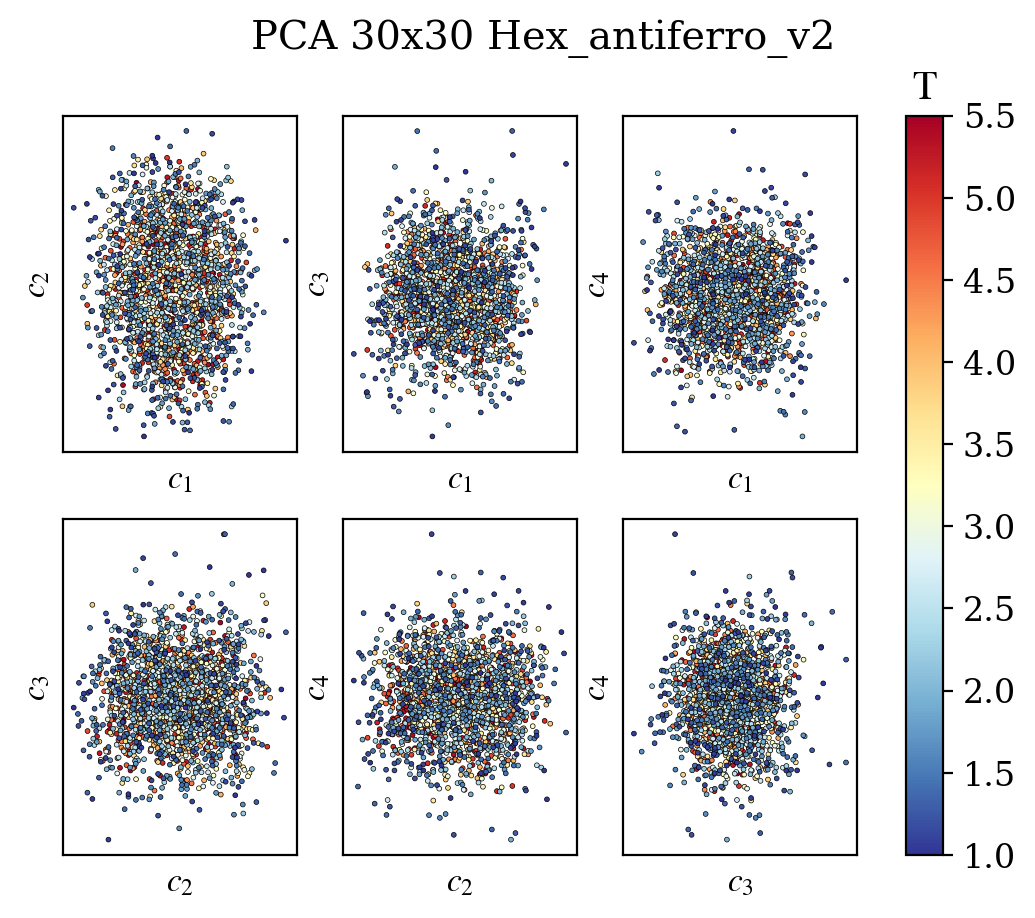

In [16]:

fig_PCA_1

In [17]:
#fig_tSNE_2


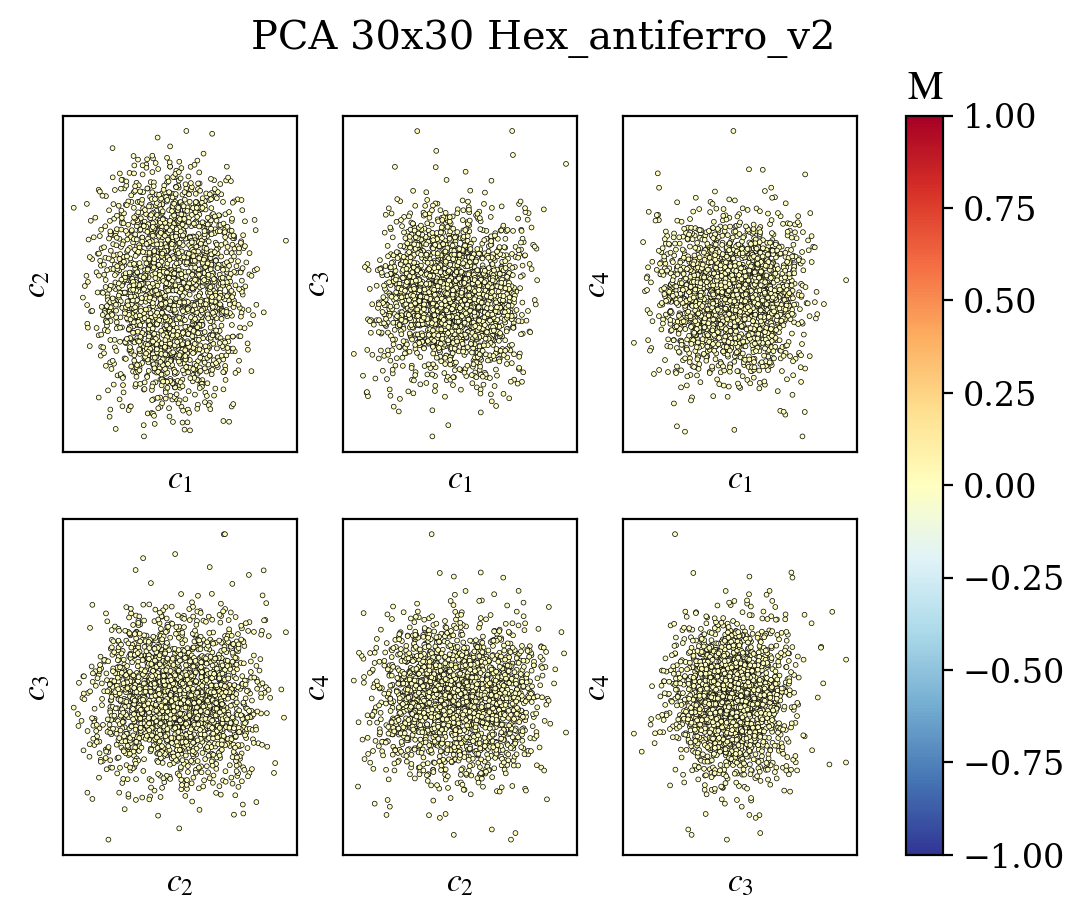

In [18]:
#fig_PCA_2.tight_layout()
fig_PCA_2

In [19]:
#fig_tSNE_3

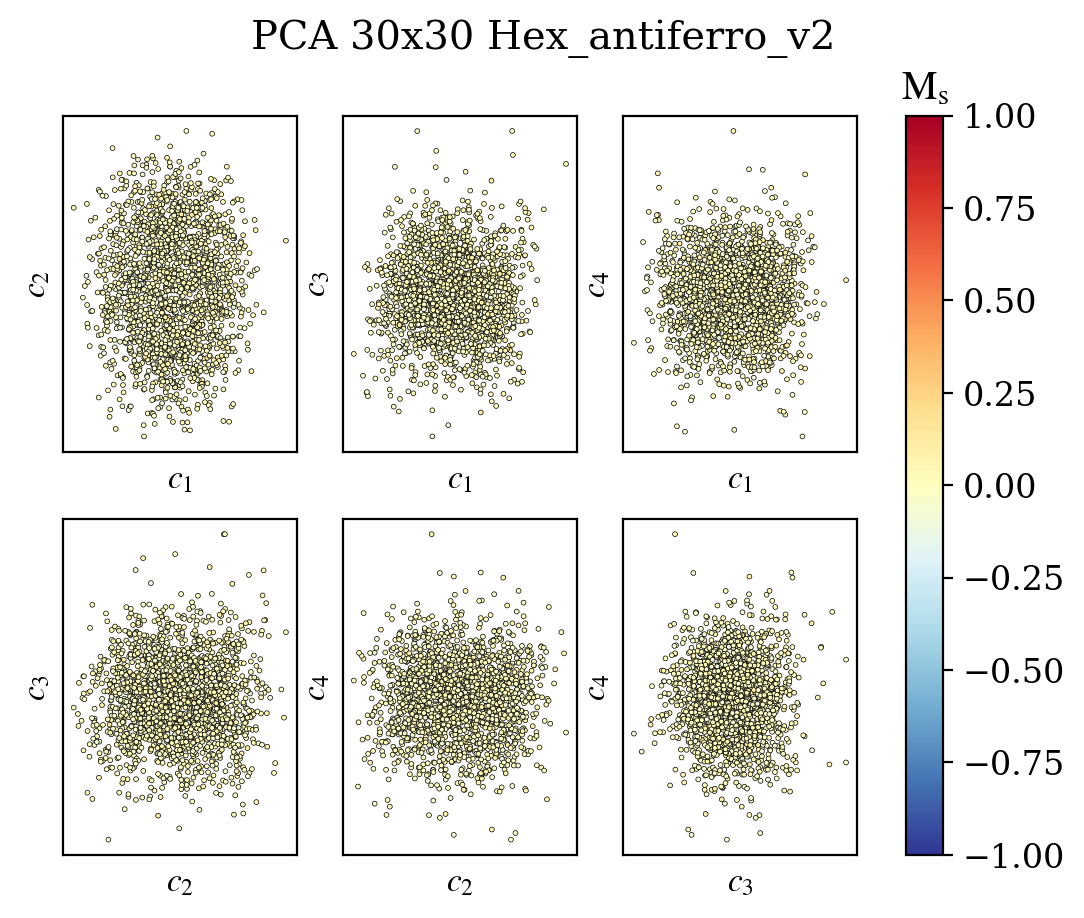

In [20]:
fig_PCA_3

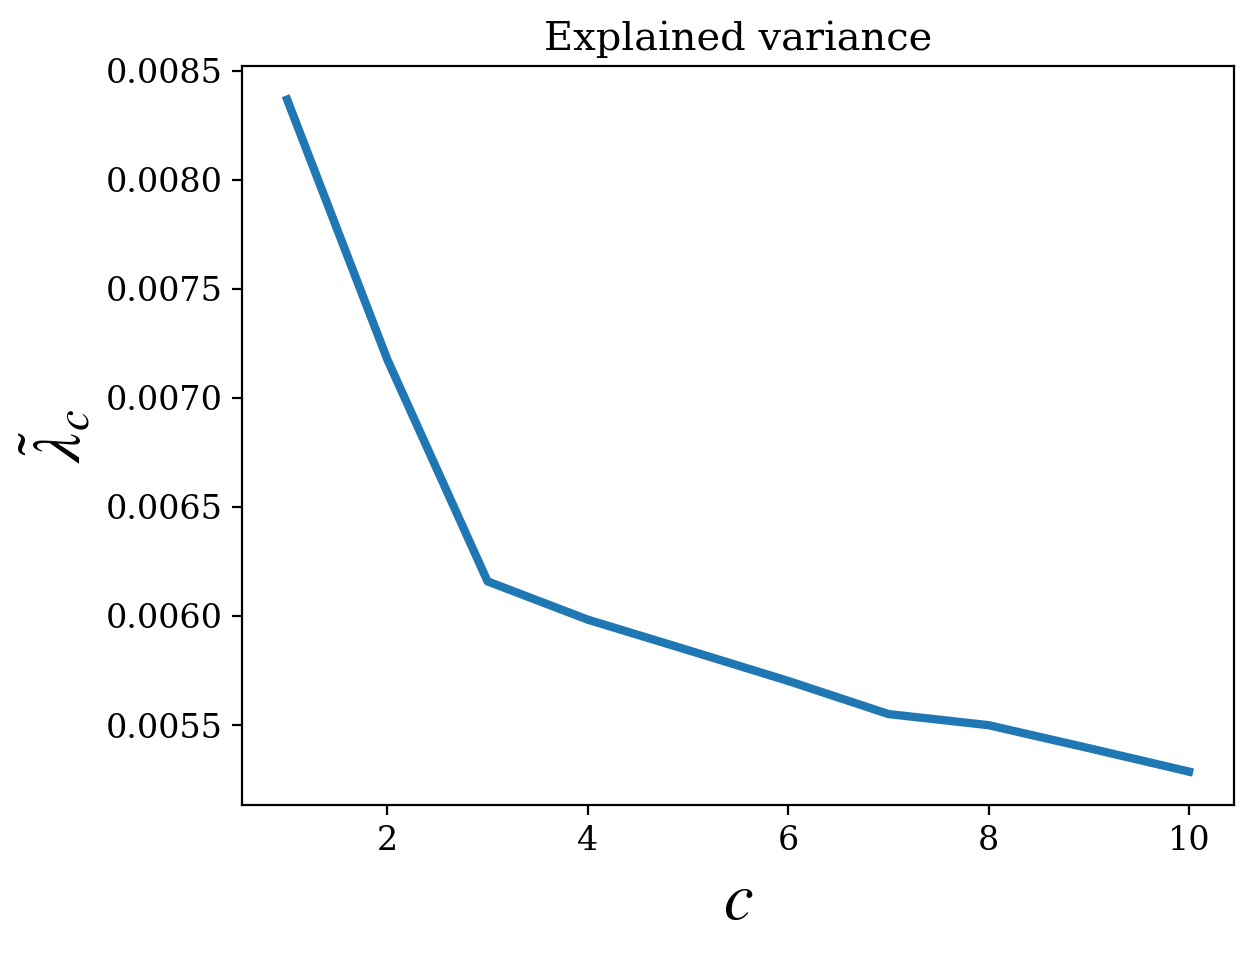

In [21]:
fig_varPCA

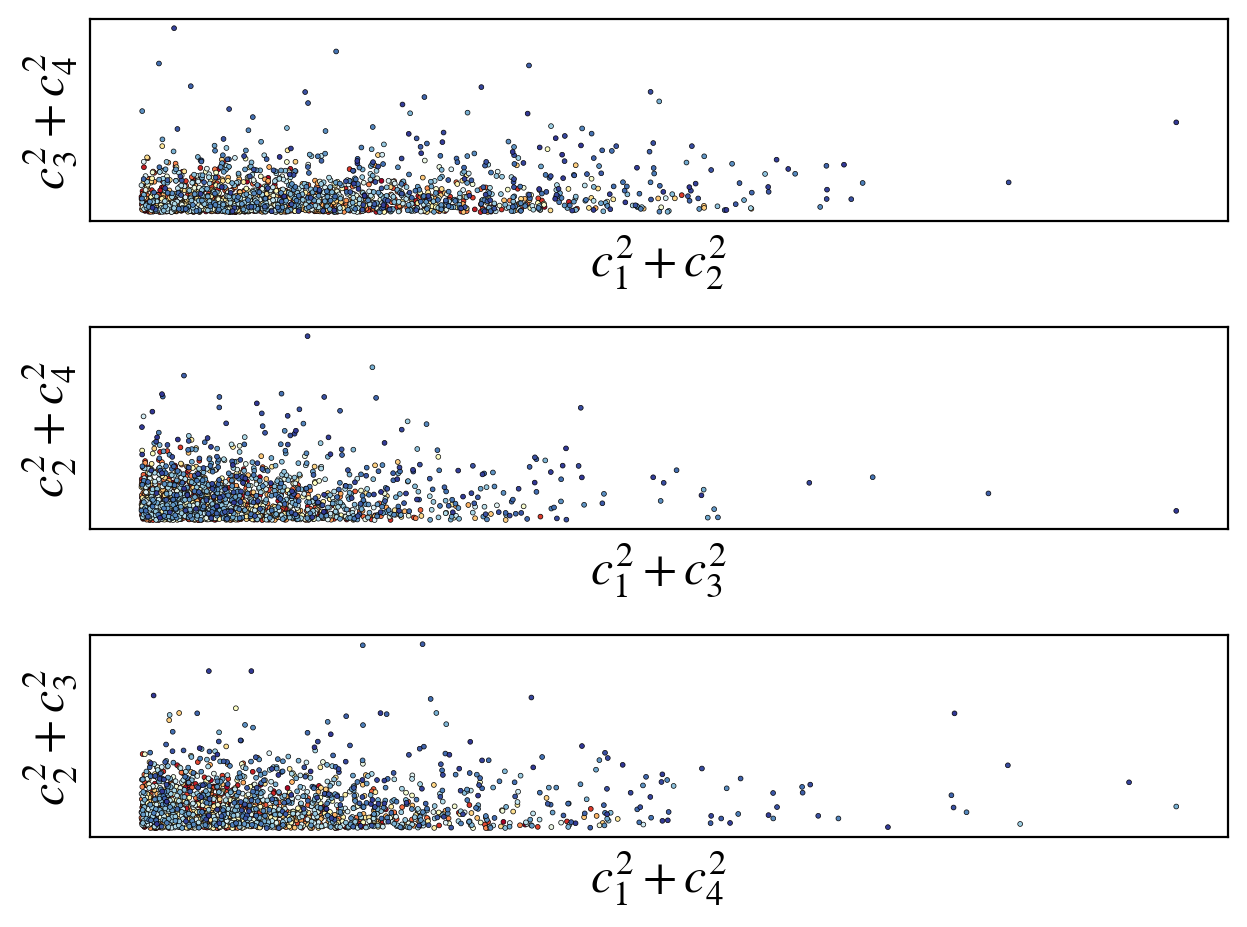

In [22]:
fig_PCA_Circular.tight_layout()
fig_PCA_Circular